
# CH-SIMS — Processed Unaligned EDA


### EDA focus
1. Dataset structure and tensor dimensions
2. Split/sample distribution
3. Target statistics and sentiment distribution
4. T/A/V target distributions when available
5. T/A/V vs fused-target correlation
6. Pairwise modality disagreement
7. Sequence-length comparison
8. Feature-norm / energy comparison
9. Outlier diagnostics using the reference notebook's IQR idea
10. PCA visualization of processed T/A/V representations
11. Missing / zero / NaN / Inf checks
12. A compact T/A/V unimodal-vs-fusion baseline for interpretation

**Important:** CH-SIMS is treated as **unaligned only**. There is no aligned dataset and no aligned-vs-unaligned analysis.


## 0. Imports and setup

In [2]:

import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("=" * 80)
print("CH-SIMS — PROCESSED UNALIGNED EDA")
print("=" * 80)


CH-SIMS — PROCESSED UNALIGNED EDA


## 1. Load the original processed CH-SIMS file

In [1]:

# ============================================================
# 1. MOUNT GOOGLE DRIVE + USE THE EXISTING PREPROCESSED PATH
# ============================================================

from google.colab import drive
from pathlib import Path
import os
import pickle

drive.mount('/content/drive')

MYDRIVE = Path('/content/drive/MyDrive')

# IMPORTANT:
# This is the PREPROCESSED CH-SIMS folder used in the earlier
# MPLMM preprocessing/EDA notebook.
# We are NOT using the raw CH-SIMS / End-to-End extraction paths.

CHSIMS_DIR = MYDRIVE / 'CH-SIMS' / 'Processed'

print("CH-SIMS processed folder:", CHSIMS_DIR)
print("Folder exists:", CHSIMS_DIR.exists())

if not CHSIMS_DIR.exists():
    raise FileNotFoundError(
        f"CH-SIMS Processed folder not found:\n{CHSIMS_DIR}\n"
        "Please check the existing Drive folder used by your preprocessing notebook."
    )

# Find only already-preprocessed feature files.
processed_files = sorted(
    p for p in CHSIMS_DIR.rglob('*')
    if p.is_file() and p.suffix.lower() in {'.pkl', '.pickle'}
)

print("\nProcessed pickle files found:")
for p in processed_files:
    print(" -", p)

if not processed_files:
    raise FileNotFoundError(
        f"No .pkl/.pickle file found inside:\n{CHSIMS_DIR}"
    )

# Prefer an explicitly unaligned/no-align processed file.
unaligned_candidates = [
    p for p in processed_files
    if any(k in p.name.lower() for k in ['unalign', 'noalign', 'unaligned'])
]

if len(unaligned_candidates) == 1:
    DATA_PATH = unaligned_candidates[0]
elif len(unaligned_candidates) > 1:
    DATA_PATH = unaligned_candidates[0]
    print("\nMultiple unaligned files found; using:", DATA_PATH)
else:
    # If the existing Processed folder contains only one feature pickle,
    # use that file rather than inventing a new path.
    if len(processed_files) == 1:
        DATA_PATH = processed_files[0]
    else:
        raise RuntimeError(
            "Multiple processed pickle files were found but none is clearly "
            "named unaligned/noalign. Set DATA_PATH manually to the file "
            "already used in your preprocessing notebook."
        )

print("\nSelected PREPROCESSED CH-SIMS file:")
print(DATA_PATH)

with open(DATA_PATH, 'rb') as f:
    dataset = pickle.load(f)

print("\nPickle loaded successfully.")
print("Top-level keys:", list(dataset.keys()))


Mounted at /content/drive
CH-SIMS processed folder: /content/drive/MyDrive/CH-SIMS/Processed
Folder exists: True

Processed pickle files found:
 - /content/drive/MyDrive/CH-SIMS/Processed/unaligned_39.pkl

Selected PREPROCESSED CH-SIMS file:
/content/drive/MyDrive/CH-SIMS/Processed/unaligned_39.pkl

Pickle loaded successfully.
Top-level keys: ['train', 'valid', 'test']


## 2. Structural inspection — samples, keys, shapes and dtypes

In [3]:

def get_keys(split_dict):
    t_k = next((k for k in ['text', 'feature_T', 'text_mmsa'] if k in split_dict), None)
    a_k = next((k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in split_dict), None)
    v_k = next((k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in split_dict), None)
    l_k = next((k for k in ['labels', 'label', 'regression_labels'] if k in split_dict), None)

    lt_k = next((k for k in ['labels_T', 'label_T', 'label_t'] if k in split_dict), None)
    la_k = next((k for k in ['labels_A', 'label_A', 'label_a'] if k in split_dict), None)
    lv_k = next((k for k in ['labels_V', 'label_V', 'label_v'] if k in split_dict), None)

    id_k = next((k for k in ['id', 'ids', 'sample_id', 'raw_text'] if k in split_dict), None)
    return t_k, a_k, v_k, l_k, lt_k, la_k, lv_k, id_k


structure_rows = []

for split in ['train', 'valid', 'test']:
    if split not in dataset:
        continue

    d = dataset[split]
    t_k, a_k, v_k, l_k, lt_k, la_k, lv_k, id_k = get_keys(d)

    structure_rows.append({
        'Split': split.upper(),
        'Samples': len(d[l_k]) if l_k else 'N/A',
        'Text key': t_k,
        'Text shape': str(np.asarray(d[t_k]).shape) if t_k else 'N/A',
        'Audio key': a_k,
        'Audio shape': str(np.asarray(d[a_k]).shape) if a_k else 'N/A',
        'Vision key': v_k,
        'Vision shape': str(np.asarray(d[v_k]).shape) if v_k else 'N/A',
        'Target key': l_k,
        'Target shape': str(np.asarray(d[l_k]).shape) if l_k else 'N/A',
        'T-label': lt_k or 'Not present',
        'A-label': la_k or 'Not present',
        'V-label': lv_k or 'Not present',
        'Feature dtype': str(np.asarray(d[t_k]).dtype) if t_k else 'N/A',
    })

df_structure = pd.DataFrame(structure_rows)
display(df_structure)

# Save beside the notebook's configured Drive output folder.
OUT_DIR = Path('/content/drive/MyDrive/mplmm_final_deliverables/outputs/CH-SIMS')
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

df_structure.to_csv(TABLE_DIR / '01_structure.csv', index=False)


,Split,Samples,Text key,Text shape,Audio key,Audio shape,Vision key,Vision shape,Target key,Target shape,T-label,A-label,V-label,Feature dtype
0,TRAIN,1368,text,"(1368, 39, 768)",audio,"(1368, 400, 33)",vision,"(1368, 55, 709)",regression_labels,"(1368,)",Not present,Not present,Not present,float32
1,VALID,456,text,"(456, 39, 768)",audio,"(456, 400, 33)",vision,"(456, 55, 709)",regression_labels,"(456,)",Not present,Not present,Not present,float32
2,TEST,457,text,"(457, 39, 768)",audio,"(457, 400, 33)",vision,"(457, 55, 709)",regression_labels,"(457,)",Not present,Not present,Not present,float32


## 3. Build a sample-level EDA table

In [4]:

dfs = {}

for split in ['train', 'valid', 'test']:
    if split not in dataset:
        continue

    d = dataset[split]
    t_k, a_k, v_k, l_k, lt_k, la_k, lv_k, id_k = get_keys(d)

    labels = np.asarray(d[l_k]).squeeze()

    t_feats = d[t_k]
    a_feats = d[a_k]
    v_feats = d[v_k]

    rows = []

    for i in range(len(labels)):
        rows.append({
            'sample_id': d[id_k][i] if id_k else f'{split}_{i}',
            'split': split,
            'label': float(np.asarray(labels[i]).reshape(-1)[0]),

            # Reference-style temporal diagnostics
            'seq_len_text': np.asarray(t_feats[i]).shape[0],
            'seq_len_audio': np.asarray(a_feats[i]).shape[0],
            'seq_len_vision': np.asarray(v_feats[i]).shape[0],

            # Reference-style feature energy / norms
            'text_feat_norm': float(np.linalg.norm(t_feats[i])),
            'audio_feat_norm': float(np.linalg.norm(a_feats[i])),
            'vision_feat_norm': float(np.linalg.norm(v_feats[i])),

            'text_dim': np.asarray(t_feats[i]).shape[-1],
            'audio_dim': np.asarray(a_feats[i]).shape[-1],
            'vision_dim': np.asarray(v_feats[i]).shape[-1],

            'label_T': float(np.asarray(d[lt_k][i]).reshape(-1)[0]) if lt_k else np.nan,
            'label_A': float(np.asarray(d[la_k][i]).reshape(-1)[0]) if la_k else np.nan,
            'label_V': float(np.asarray(d[lv_k][i]).reshape(-1)[0]) if lv_k else np.nan,
        })

    dfs[split] = pd.DataFrame(rows)

df_all = pd.concat(dfs.values(), ignore_index=True)

display(df_all.head())
print("\nDataset-level shape:", df_all.shape)

df_all.to_csv(TABLE_DIR / '02_sample_level_eda.csv', index=False)


,sample_id,split,label,seq_len_text,seq_len_audio,seq_len_vision,text_feat_norm,audio_feat_norm,vision_feat_norm,text_dim,audio_dim,vision_dim,label_T,label_A,label_V
0,video_0018$_$0004,train,-1.0,39,400,55,128.965805,1758.059264,8.688335e+03,768,33,709,NaN,NaN,NaN
1,video_0029$_$0010,train,-1.0,39,400,55,134.309616,3964.668579,2.446944e+08,768,33,709,NaN,NaN,NaN
2,video_0038$_$0040,train,0.6,39,400,55,126.868629,2708.988649,7.654570e+03,768,33,709,NaN,NaN,NaN
3,video_0032$_$0006,train,-0.2,39,400,55,132.569778,5768.577458,1.330954e+04,768,33,709,NaN,NaN,NaN
4,video_0025$_$0006,train,-1.0,39,400,55,126.715919,2107.908877,6.276658e+03,768,33,709,NaN,NaN,NaN



Dataset-level shape: (2281, 15)


## 4. Split distribution and target statistics

,split,samples
0,test,457
1,train,1368
2,valid,456


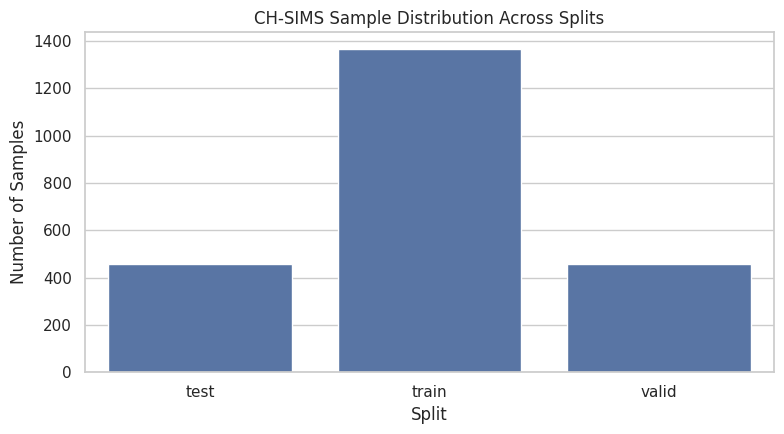

,count,mean,std,min,median,max
split,,,,,,
test,457,-0.192560,0.691576,-1.0,-0.2,1.0
train,1368,-0.192836,0.691155,-1.0,-0.2,1.0
valid,456,-0.194298,0.691082,-1.0,-0.2,1.0


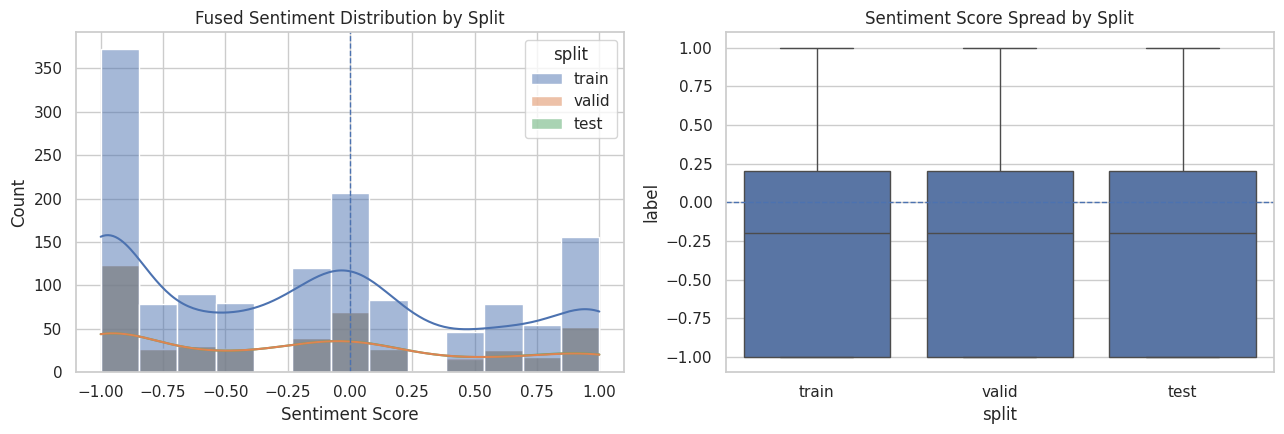

In [5]:

# Split sizes
split_counts = df_all.groupby('split').size().reset_index(name='samples')
display(split_counts)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=split_counts, x='split', y='samples')
plt.title("CH-SIMS Sample Distribution Across Splits")
plt.xlabel("Split")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(FIG_DIR / '01_split_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

# Target statistics
target_stats = df_all.groupby('split')['label'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
)
display(target_stats)

target_stats.to_csv(TABLE_DIR / '03_target_statistics.csv')

# Continuous target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    data=df_all,
    x='label',
    hue='split',
    kde=True,
    common_norm=False,
    ax=axes[0]
)
axes[0].axvline(0, linestyle='--', linewidth=1)
axes[0].set_title("Fused Sentiment Distribution by Split")
axes[0].set_xlabel("Sentiment Score")

sns.boxplot(
    data=df_all,
    x='split',
    y='label',
    ax=axes[1]
)
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_title("Sentiment Score Spread by Split")

plt.tight_layout()
plt.savefig(FIG_DIR / '02_target_distribution.png', dpi=180, bbox_inches='tight')
plt.show()


## 5. Sentiment polarity balance

,split,polarity,samples
0,test,Negative,248
1,test,Neutral,69
2,test,Positive,140
3,train,Negative,742
4,train,Neutral,207
5,train,Positive,419
6,valid,Negative,248
7,valid,Neutral,69
8,valid,Positive,139


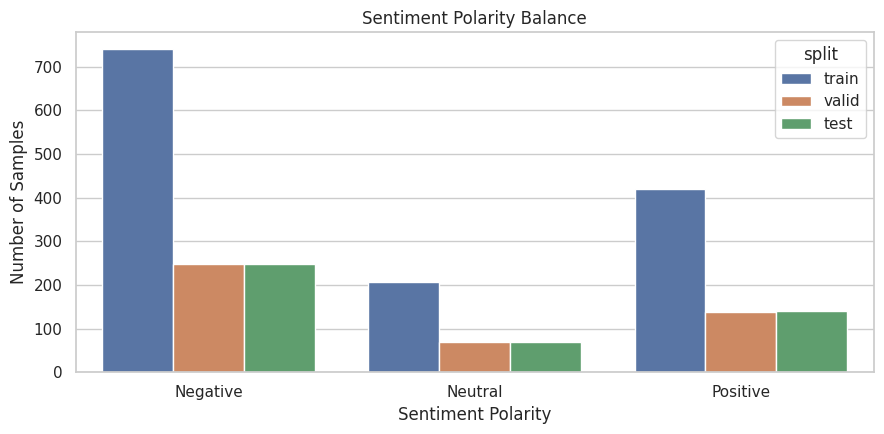

In [6]:

df_all['polarity'] = np.where(
    df_all['label'] < 0,
    'Negative',
    np.where(df_all['label'] > 0, 'Positive', 'Neutral')
)

polarity_counts = (
    df_all.groupby(['split', 'polarity'])
    .size()
    .reset_index(name='samples')
)

display(polarity_counts)

plt.figure(figsize=(9, 4.5))
sns.countplot(
    data=df_all,
    x='polarity',
    hue='split',
    order=['Negative', 'Neutral', 'Positive']
)
plt.title("Sentiment Polarity Balance")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(FIG_DIR / '03_polarity_balance.png', dpi=180, bbox_inches='tight')
plt.show()


## 6. Text vs Audio vs Vision target distributions

In [7]:

label_cols = ['label_T', 'label_A', 'label_V', 'label']
available = [c for c in label_cols if c in df_all.columns and df_all[c].notna().any()]

print("Available target signals:", available)

if len(available) >= 2:
    plt.figure(figsize=(11, 5))

    display_names = {
        'label_T': 'Text (T)',
        'label_A': 'Audio (A)',
        'label_V': 'Vision (V)',
        'label': 'Fused Target'
    }

    for col in available:
        sns.kdeplot(
            df_all[col].dropna(),
            label=display_names.get(col, col),
            linewidth=2
        )

    plt.axvline(0, linestyle='--', linewidth=1)
    plt.title("Distribution Densities: T vs A vs V vs Fused Target")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '04_modality_target_densities.png', dpi=180, bbox_inches='tight')
    plt.show()

    modality_stats = df_all[available].describe().T
    display(modality_stats)
    modality_stats.to_csv(TABLE_DIR / '04_modality_target_statistics.csv')
else:
    print(
        "True modality-specific labels are not present. "
        "The notebook will not invent them; later sections use processed-feature analysis instead."
    )


Available target signals: ['label']
True modality-specific labels are not present. The notebook will not invent them; later sections use processed-feature analysis instead.


## 7. Correlation between T/A/V labels and fused target

In [8]:

available_corr = [c for c in ['label', 'label_T', 'label_A', 'label_V']
                  if c in df_all.columns and df_all[c].notna().any()]

if len(available_corr) >= 2:
    corr_matrix = df_all[available_corr].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=1
    )
    plt.title("Pearson Correlation: T/A/V Labels and Fused Target")
    plt.tight_layout()
    plt.savefig(FIG_DIR / '05_target_correlation_heatmap.png', dpi=180, bbox_inches='tight')
    plt.show()

    display(corr_matrix)
    corr_matrix.to_csv(TABLE_DIR / '05_target_correlations.csv')
else:
    print("No multiple target signals are available for a target-correlation heatmap.")


No multiple target signals are available for a target-correlation heatmap.


## 8. Pairwise modality disagreement — reference EDA

In [9]:

true_label_pairs = [
    ('label_T', 'label_A', 'Text vs Audio'),
    ('label_T', 'label_V', 'Text vs Vision'),
    ('label_A', 'label_V', 'Audio vs Vision')
]

available_pairs = [
    p for p in true_label_pairs
    if p[0] in df_all.columns and p[1] in df_all.columns
    and df_all[p[0]].notna().any() and df_all[p[1]].notna().any()
]

if available_pairs:
    diff_frames = []

    for c1, c2, name in available_pairs:
        col = name.replace(' ', '_') + '_conflict'
        df_all[col] = np.abs(df_all[c1] - df_all[c2])
        diff_frames.append((col, name))

    fig, axes = plt.subplots(
        1, len(diff_frames),
        figsize=(5 * len(diff_frames), 4.5),
        sharey=True
    )

    if len(diff_frames) == 1:
        axes = [axes]

    for ax, (col, name) in zip(axes, diff_frames):
        sns.histplot(
            df_all[col].dropna(),
            bins=25,
            kde=True,
            element='step',
            ax=ax
        )
        ax.set_title(name + " Conflict")
        ax.set_xlabel("|Label A - Label B|")
        ax.set_ylabel("Frequency")

    plt.suptitle(
        "Pairwise Modal Discrepancy Distributions",
        fontsize=13,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / '06_pairwise_modality_disagreement.png',
                dpi=180, bbox_inches='tight')
    plt.show()

    for col, name in diff_frames:
        print(
            f"{name}: median disagreement = "
            f"{df_all[col].median():.4f}"
        )

    df_all[[x[0] for x in diff_frames]].describe().to_csv(
        TABLE_DIR / '06_modality_disagreement_statistics.csv'
    )
else:
    print(
        "True modality-specific labels are absent, so pairwise label disagreement "
        "cannot be computed directly."
    )


True modality-specific labels are absent, so pairwise label disagreement cannot be computed directly.


## 10. Raw processed-feature norm distributions — reference outlier diagnostic

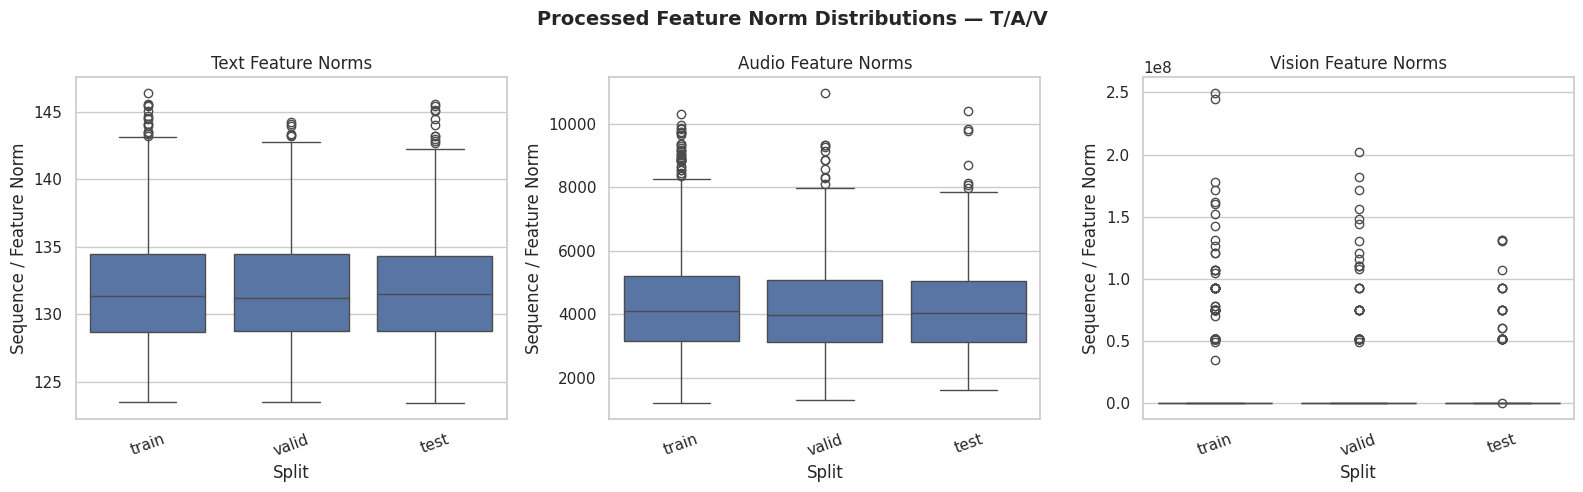

,count,mean,std,min,25%,50%,75%,max
text_feat_norm,2281.0,1.319648e+02,4.229394e+00,123.411087,128.726181,131.375046,134.425705,1.463959e+02
audio_feat_norm,2281.0,4.303091e+03,1.552073e+03,1209.444062,3143.571935,4059.162616,5160.669417,1.097865e+04
vision_feat_norm,2281.0,7.034089e+06,2.428876e+07,3264.573337,9825.261837,11908.049949,14483.302642,2.496383e+08


In [11]:

norm_cols = {
    'text_feat_norm': 'Text',
    'audio_feat_norm': 'Audio',
    'vision_feat_norm': 'Vision'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, name) in zip(axes, norm_cols.items()):
    sns.boxplot(
        y=df_all[col],
        x=df_all['split'],
        ax=ax,
        showfliers=True
    )
    ax.set_title(f"{name} Feature Norms")
    ax.set_xlabel("Split")
    ax.set_ylabel("Sequence / Feature Norm")
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(
    "Processed Feature Norm Distributions — T/A/V",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_feature_norm_boxplots.png', dpi=180, bbox_inches='tight')
plt.show()

norm_stats = df_all[list(norm_cols.keys())].describe().T
display(norm_stats)
norm_stats.to_csv(TABLE_DIR / '08_feature_norm_statistics.csv')


## 11. Vision IQR outlier diagnostics — adapted from the reference pipeline

In [13]:

# Here we diagnose outliers without deleting samples from the processed file.

train_df = df_all[df_all['split'] == 'train'].copy()

Q1 = train_df['vision_feat_norm'].quantile(0.25)
Q3 = train_df['vision_feat_norm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

vision_outlier_mask = (
    (train_df['vision_feat_norm'] < lower_bound) |
    (train_df['vision_feat_norm'] > upper_bound)
)

num_outliers = int(vision_outlier_mask.sum())

print("VISION IQR OUTLIER DIAGNOSTIC")
print("-" * 60)
print(f"Q1                    : {Q1:.4f}")
print(f"Q3                    : {Q3:.4f}")
print(f"IQR                   : {IQR:.4f}")
print(f"Lower bound           : {lower_bound:.4f}")
print(f"Upper bound           : {upper_bound:.4f}")
print(f"Outliers              : {num_outliers}")
print(f"Outlier percentage    : {100 * num_outliers / len(train_df):.2f}%")




VISION IQR OUTLIER DIAGNOSTIC
------------------------------------------------------------
Q1                    : 9783.1996
Q3                    : 14564.9177
IQR                   : 4781.7181
Lower bound           : 2610.6225
Upper bound           : 21737.4948
Outliers              : 125
Outlier percentage    : 9.14%


## 12. Feature quality — NaN, Inf and zero-vector checks

In [14]:

quality_rows = []

for split in ['train', 'valid', 'test']:
    if split not in dataset:
        continue

    d = dataset[split]
    t_k, a_k, v_k, l_k, *_ = get_keys(d)

    for modality, key in [
        ('Text', t_k),
        ('Audio', a_k),
        ('Vision', v_k)
    ]:
        arr = np.asarray(d[key])

        quality_rows.append({
            'split': split,
            'modality': modality,
            'shape': str(arr.shape),
            'dtype': str(arr.dtype),
            'nan_count': int(np.isnan(arr).sum()) if np.issubdtype(arr.dtype, np.number) else 'N/A',
            'inf_count': int(np.isinf(arr).sum()) if np.issubdtype(arr.dtype, np.number) else 'N/A',
            'zero_elements': int(np.sum(arr == 0)) if np.issubdtype(arr.dtype, np.number) else 'N/A',
        })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)
quality_df.to_csv(TABLE_DIR / '09_feature_quality.csv', index=False)


,split,modality,shape,dtype,nan_count,inf_count,zero_elements
0,train,Text,"(1368, 39, 768)",float32,0,0,0
1,train,Audio,"(1368, 400, 33)",float64,0,0,10891275
2,train,Vision,"(1368, 55, 709)",float64,0,0,32554472
3,valid,Text,"(456, 39, 768)",float32,0,0,0
4,valid,Audio,"(456, 400, 33)",float64,0,0,3691234
5,valid,Vision,"(456, 55, 709)",float64,0,0,11088918
6,test,Text,"(457, 39, 768)",float32,0,0,0
7,test,Audio,"(457, 400, 33)",float64,0,0,3661767
8,test,Vision,"(457, 55, 709)",float64,0,0,10943809


## 13. PCA of processed T/A/V representations

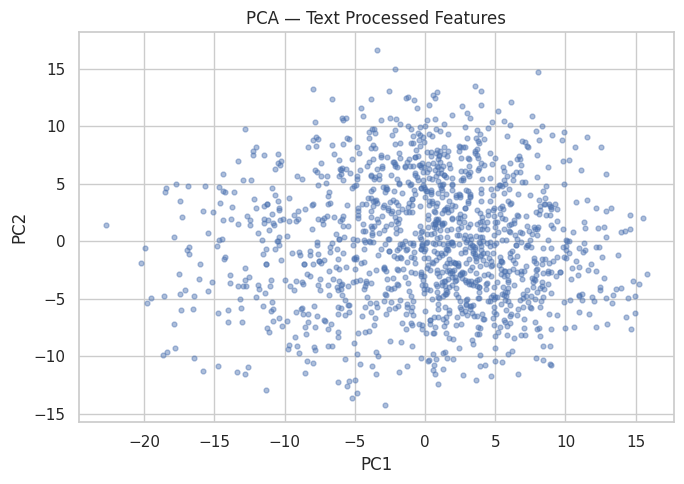

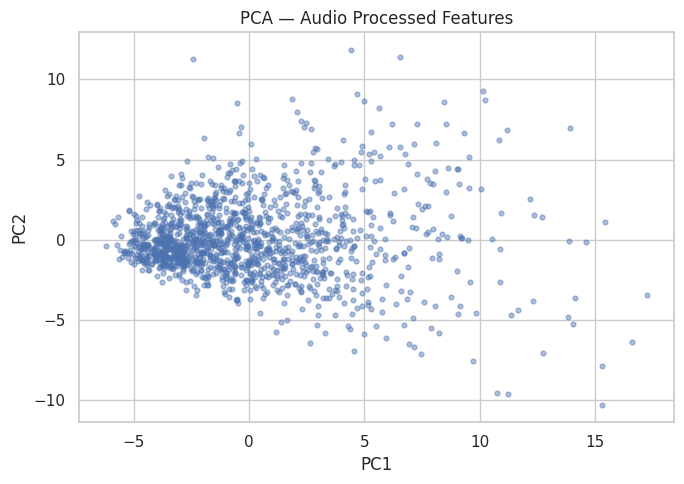

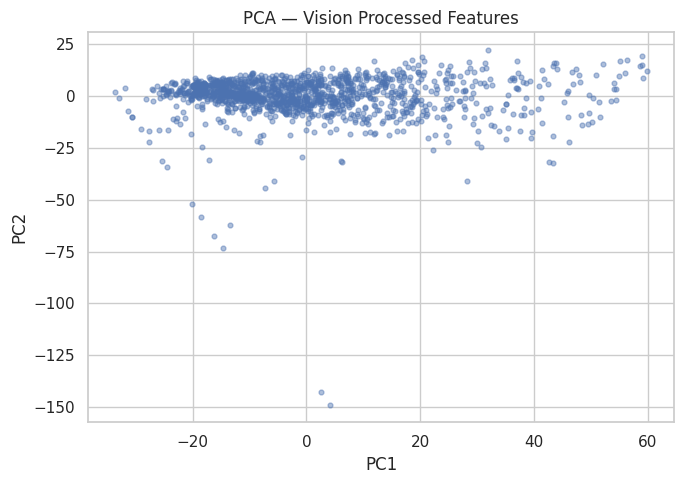

In [15]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Mean-pool only for visualization; the original pickle is not changed.
def mean_pool(x):
    arr = np.asarray(x, dtype=np.float32)

    if arr.ndim == 1:
        return arr.reshape(1, -1)

    if arr.ndim == 2:
        return arr.mean(axis=0, keepdims=True)

    return arr.reshape(arr.shape[0], -1).mean(axis=1, keepdims=True)

# Use train samples and preserve one row per sample.
train_data = dataset['train']
t_k, a_k, v_k, l_k, *_ = get_keys(train_data)

modality_arrays = {
    'Text': np.asarray(train_data[t_k]),
    'Audio': np.asarray(train_data[a_k]),
    'Vision': np.asarray(train_data[v_k])
}

for modality, arr in modality_arrays.items():

    # Standard case: N x T x D
    if arr.ndim >= 3:
        X = arr.mean(axis=1)
    elif arr.ndim == 2:
        X = arr
    else:
        X = arr.reshape(-1, 1)

    X = np.nan_to_num(
        X.astype(np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if X.shape[0] < 3 or X.shape[1] < 2:
        print(f"Skipping PCA for {modality}: insufficient dimensions.")
        continue

    # Limit dimensions if necessary for stable/fast EDA.
    if X.shape[1] > 500:
        rng = np.random.default_rng(42)
        cols = rng.choice(X.shape[1], 500, replace=False)
        X = X[:, cols]

    Xs = StandardScaler().fit_transform(X)
    Z = PCA(n_components=2, random_state=42).fit_transform(Xs)

    plt.figure(figsize=(7, 5))
    plt.scatter(Z[:, 0], Z[:, 1], s=12, alpha=0.45)
    plt.title(f"PCA — {modality} Processed Features")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / f'10_pca_{modality.lower()}.png',
        dpi=180,
        bbox_inches='tight'
    )
    plt.show()


## 14. Target vs modality feature energy

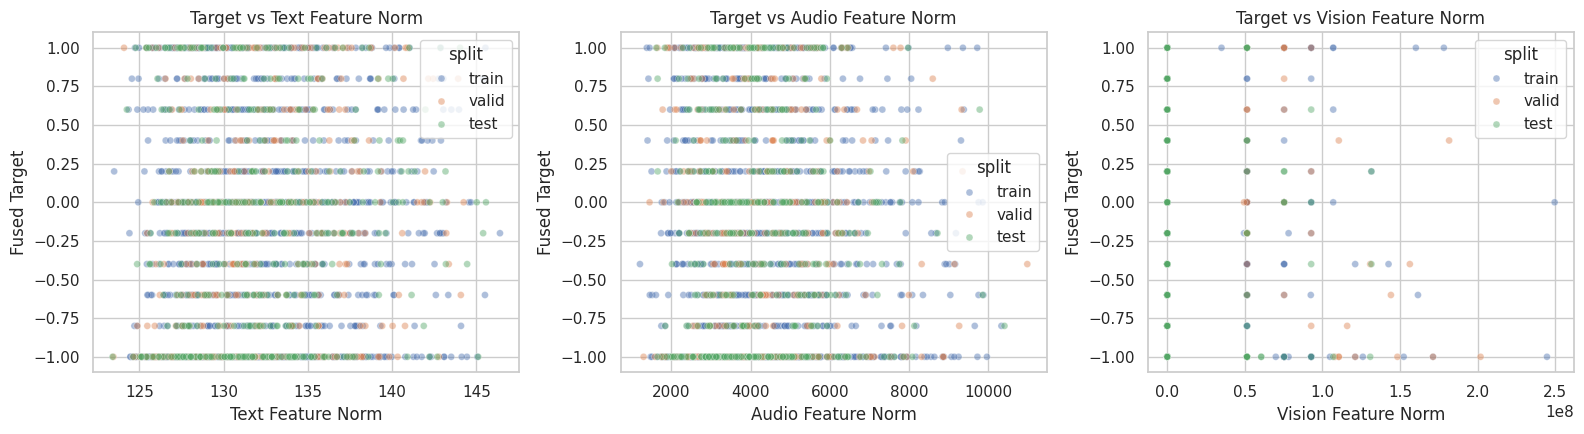

,label,text_feat_norm,audio_feat_norm,vision_feat_norm
label,1.000000,0.070557,-0.021637,-0.022151
text_feat_norm,0.070557,1.000000,0.421543,-0.006651
audio_feat_norm,-0.021637,0.421543,1.000000,0.069690
vision_feat_norm,-0.022151,-0.006651,0.069690,1.000000


In [16]:

energy_cols = [
    ('text_feat_norm', 'Text'),
    ('audio_feat_norm', 'Audio'),
    ('vision_feat_norm', 'Vision')
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (col, modality) in zip(axes, energy_cols):
    sns.scatterplot(
        data=df_all,
        x=col,
        y='label',
        hue='split',
        alpha=0.45,
        s=25,
        ax=ax
    )
    ax.set_title(f"Target vs {modality} Feature Norm")
    ax.set_xlabel(f"{modality} Feature Norm")
    ax.set_ylabel("Fused Target")

plt.tight_layout()
plt.savefig(FIG_DIR / '11_target_vs_feature_energy.png', dpi=180, bbox_inches='tight')
plt.show()

energy_corr = df_all[
    ['label', 'text_feat_norm', 'audio_feat_norm', 'vision_feat_norm']
].corr()

display(energy_corr)
energy_corr.to_csv(TABLE_DIR / '10_target_feature_energy_correlations.csv')


## 15. Compact T/A/V unimodal and fusion baseline

,Configuration,MAE,RMSE,Pearson_r
0,T-only,0.585030,0.741858,0.413897
1,A-only,0.581437,0.691875,0.107394
2,V-only,0.542324,0.642299,0.397436
3,T+A,0.605751,0.765339,0.394526
4,T+V,0.594540,0.760742,0.448458
5,A+V,0.535840,0.647147,0.397503
6,T+A+V,0.601647,0.771040,0.440343


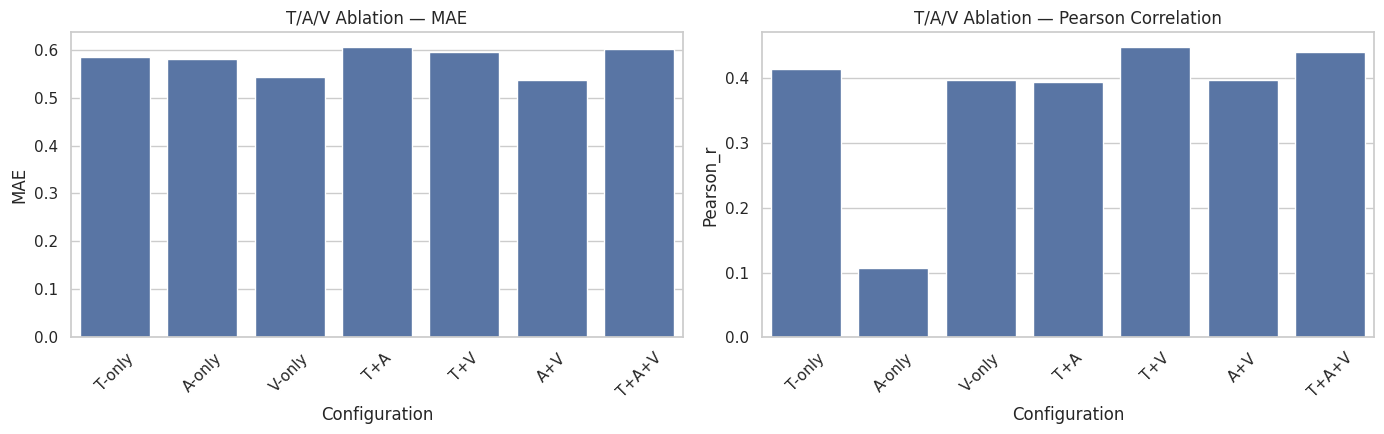

In [17]:

# This is only an interpretability baseline.
# It does not replace the MulT/model pipeline from the reference notebook.

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

def pooled_matrix(split_dict, key):
    X = np.asarray(split_dict[key], dtype=np.float32)

    if X.ndim >= 3:
        X = X.mean(axis=1)
    elif X.ndim == 1:
        X = X.reshape(-1, 1)

    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

train = dataset['train']
valid = dataset.get('valid')
test = dataset['test']

t_k, a_k, v_k, l_k, *_ = get_keys(train)

def get_split_xy(split_dict, modalities):
    keys = {'T': t_k, 'A': a_k, 'V': v_k}
    mats = [pooled_matrix(split_dict, keys[m]) for m in modalities]
    X = np.concatenate(mats, axis=1)
    y = np.asarray(split_dict[l_k]).squeeze().astype(float)
    return X, y

baseline_rows = []

for mods, name in [
    (['T'], 'T-only'),
    (['A'], 'A-only'),
    (['V'], 'V-only'),
    (['T', 'A'], 'T+A'),
    (['T', 'V'], 'T+V'),
    (['A', 'V'], 'A+V'),
    (['T', 'A', 'V'], 'T+A+V')
]:
    X_train, y_train = get_split_xy(train, mods)
    X_test, y_test = get_split_xy(test, mods)

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=10.0)
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    r = pearsonr(pred, y_test)[0] if len(y_test) > 2 else np.nan

    baseline_rows.append({
        'Configuration': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'Pearson_r': r
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

baseline_df.to_csv(TABLE_DIR / '11_tav_baseline_comparison.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.barplot(data=baseline_df, x='Configuration', y='MAE', ax=axes[0])
axes[0].set_title("T/A/V Ablation — MAE")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=baseline_df, x='Configuration', y='Pearson_r', ax=axes[1])
axes[1].set_title("T/A/V Ablation — Pearson Correlation")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / '12_tav_ablation.png', dpi=180, bbox_inches='tight')
plt.show()


## 16. Final EDA summary

In [18]:

summary = {
    'dataset': 'CH-SIMS',
    'representation': 'unaligned processed',
    'processed_pickle': DATA_PATH,
    'train_samples': len(dataset.get('train', {}).get(l_k, [])),
    'valid_samples': len(dataset.get('valid', {}).get(l_k, [])) if 'valid' in dataset else 0,
    'test_samples': len(dataset.get('test', {}).get(l_k, [])),
    'true_T_label_available': bool(df_all['label_T'].notna().any()),
    'true_A_label_available': bool(df_all['label_A'].notna().any()),
    'true_V_label_available': bool(df_all['label_V'].notna().any()),
    'output_folder': str(OUT_DIR)
}

display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

with open(OUT_DIR / 'run_summary.json', 'w') as f:
    import json
    json.dump(summary, f, indent=2, default=str)

print("\nEDA completed.")
print("Figures:", FIG_DIR)
print("Tables :", TABLE_DIR)


,value
dataset,CH-SIMS
representation,unaligned processed
processed_pickle,/content/drive/MyDrive/CH-SIMS/Processed/unali...
train_samples,1368
valid_samples,456
test_samples,457
true_T_label_available,False
true_A_label_available,False
true_V_label_available,False
output_folder,/content/drive/MyDrive/mplmm_final_deliverable...



EDA completed.
Figures: /content/drive/MyDrive/mplmm_final_deliverables/outputs/CH-SIMS/figures
Tables : /content/drive/MyDrive/mplmm_final_deliverables/outputs/CH-SIMS/tables
